# Visualisation des modèles

*Petit paragraphe de présentaion ?*

In [1]:


import numpy as np
import matplotlib.pyplot as plt

import fonctions_communes as fct
import fonctions_complet as com
import fonctions_separe as sep
import fonctions_affichage as aff

%load_ext autoreload
%autoreload 2

In [2]:
#import matplotlib.pyplot as plt
#from scipy.optimize import linprog
#import pandas as pd
#import pulp
#import networkx as nx
#from ipywidgets import interact, IntSlider

## 1. Choix des paramètres de simulation et chargement des données

### 1.1. Choix des paramètres de simulation

In [3]:
N = 5 # nombre de pays simulés

phs_capacity = 30*180 # modifié en faisant 30*
phs_power = 5*9.3 # modifié en faisant 5*
phs_eff=0.75 
ptg_capacity = 125000
ptg_init_rate = 0.75 # taux initial de remplissage des stocks (entre 0 et 1)
ptg_power_in = 60*7.66 # modifié en faisant 60*
ptg_power_out = 2*32.93 # modifié en faisant 2*
ptg_eff = 0.4

# Seulement pour le SEPARE :
penalisation = 1e10
flux_eff = 0.9

### 1.2. Chargement des données pour les années 2019 à 2023

Chargement des données pour 1 pays du code jouet et définition des capacités requises :

In [4]:
demand_N, solar_cap_N, wind_cap_N, solar_N, wind_N = fct.charge_data_5years(multi = False)
print(demand_N.shape)


Données prêtes : Matrice Solaire (8760, 5), Matrice Éolienne (8760, 5)
(8760, 5)


Chargement des capacité d'échange maximales :

In [5]:
qmax7pays = fct.capa_max_echanges()
# qmax = 10*qmax7pays[:N,:N]
qmax = qmax7pays[:N,:N]
print("Matrice des capacités d'échanges max :", qmax, sep='\n')

Matrice des capacités d'échanges max :
[[0.  0.9 0.4 1.7 0.2]
 [1.1 0.  0.  0.  0. ]
 [3.5 0.  0.  2.  0. ]
 [1.7 0.  2.8 0.  0. ]
 [1.8 0.  0.  2.4 0. ]]


### 1.3 Choix des paramètres d'affichage

## 2. Simulation des modèles "Complet" et "Séparé" sur 1 an

### 2.1. Complet

In [6]:
result_complet = com.optimize_5years(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=phs_capacity, 
    phs_power=phs_power, 
    phs_eff=phs_eff,  
    ptg_capacity=ptg_capacity,
    ptg_power_in=ptg_power_in,
    ptg_power_out=ptg_power_out,
    ptg_eff=ptg_eff
)

Interprétation graphique :

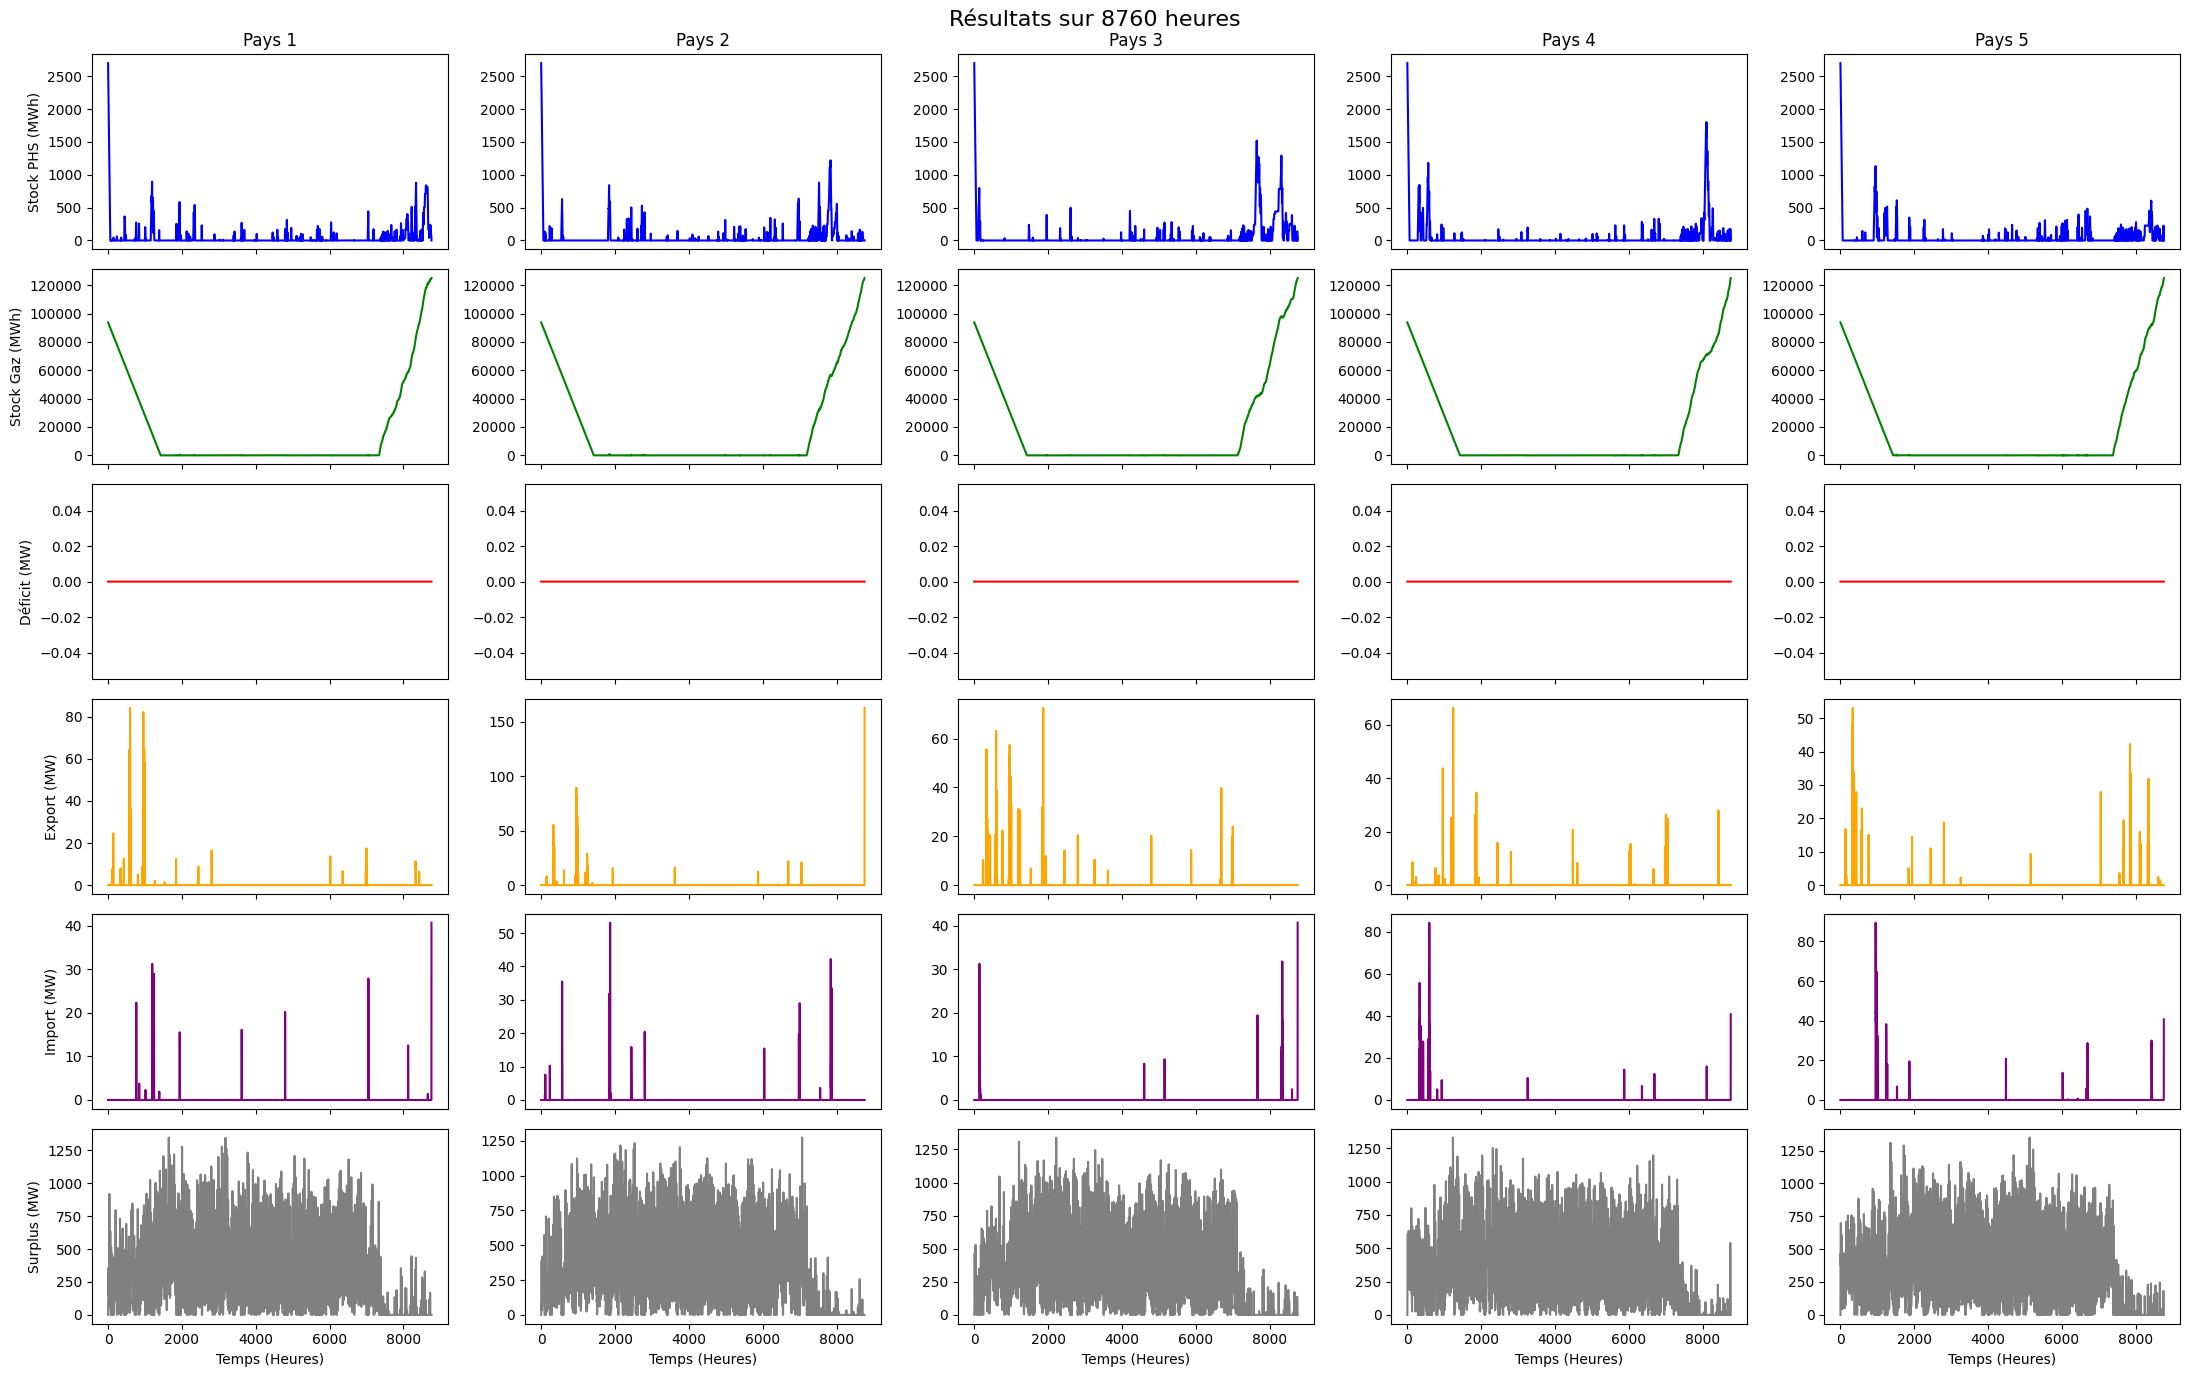

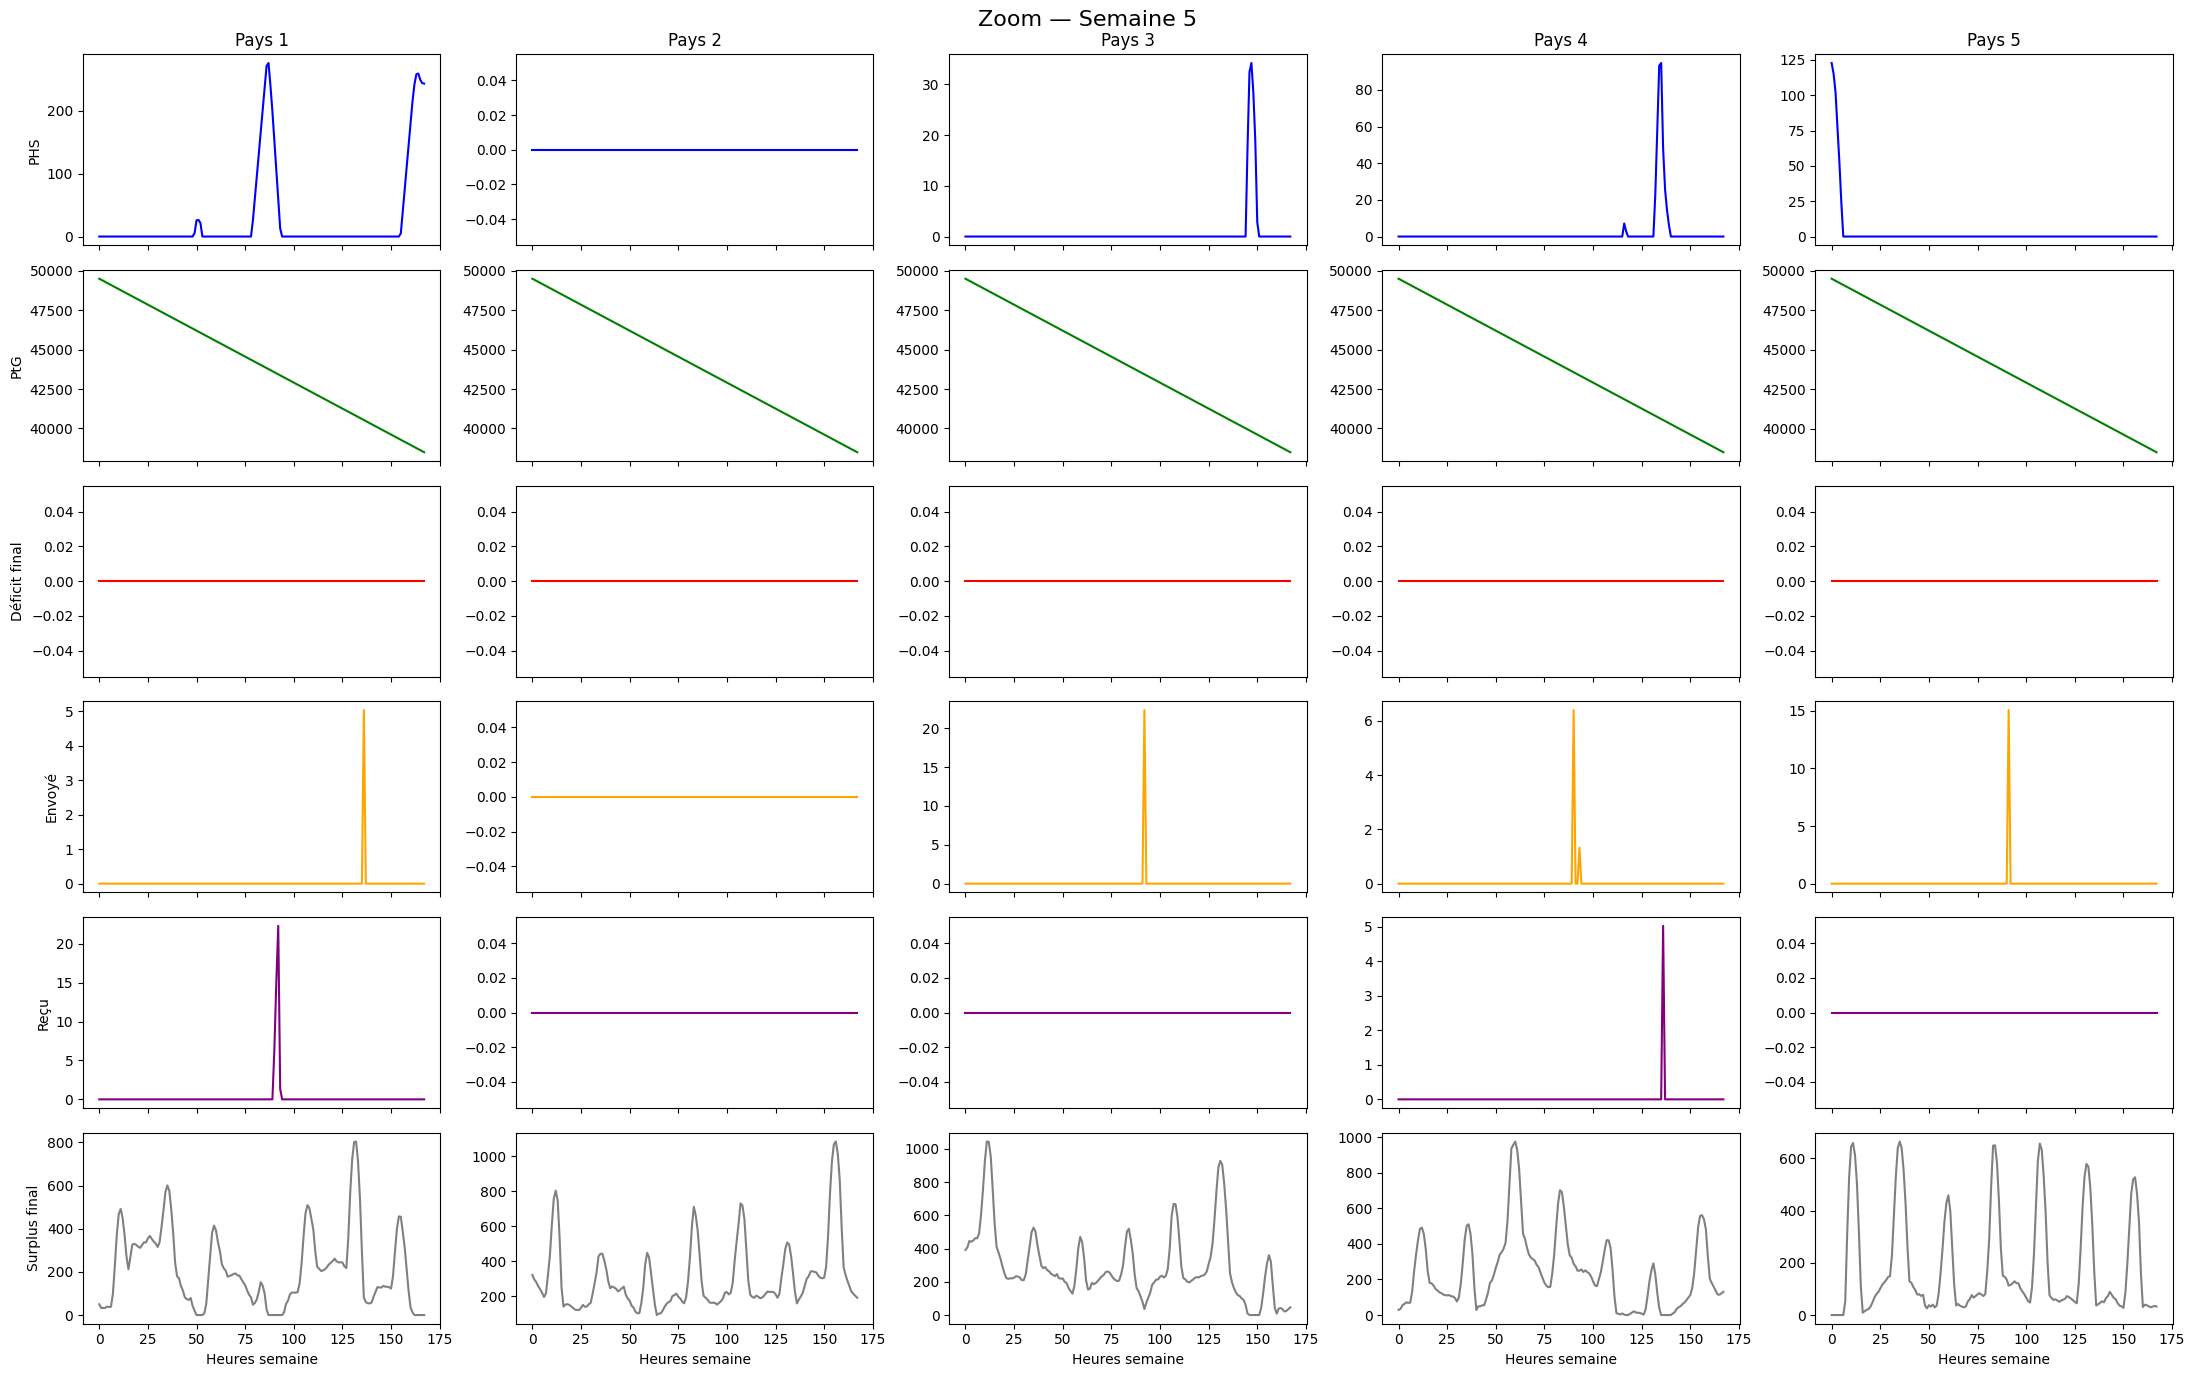

In [7]:
aff.plot_graphs(result_complet)

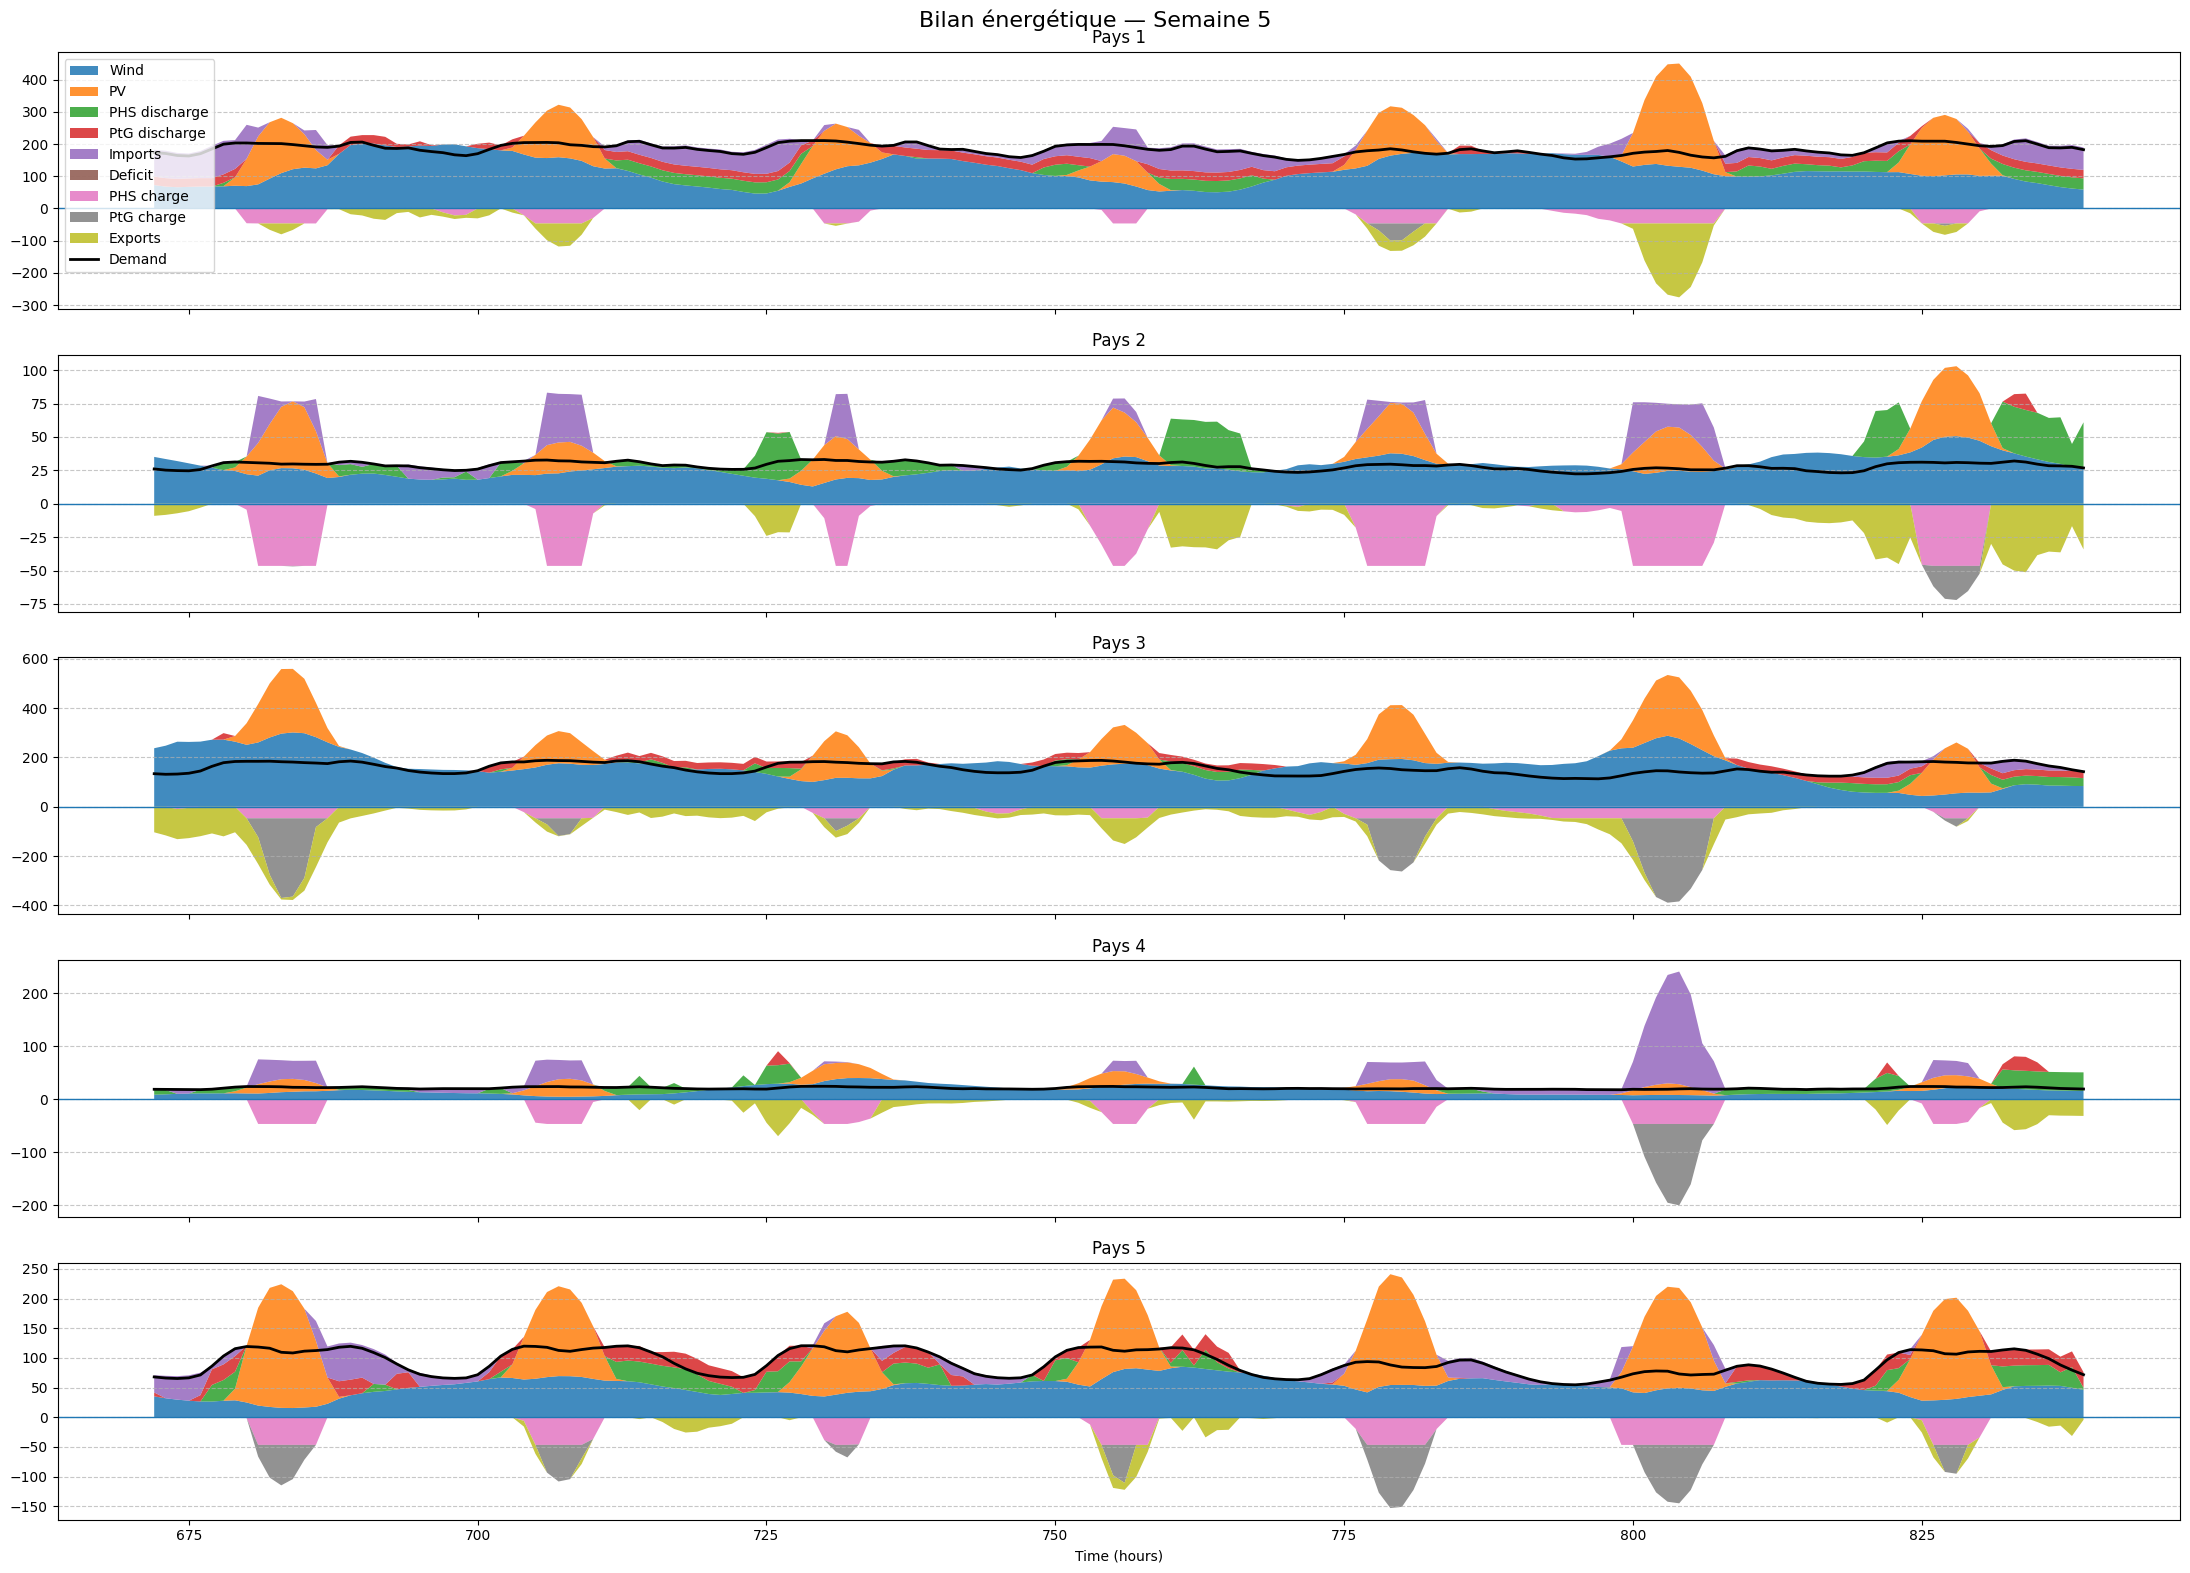

In [36]:
aff.plot_global_graph(result_complet, demand_N=demand_N, wind_N=wind_N, wind_cap_N=wind_cap_N, solar_N=solar_N, solar_cap_N=solar_cap_N, ptg_eff=ptg_eff, phs_eff=phs_eff)

### 2.2 Séparé

In [20]:
# Utilisation de la V3

result_separe = sep.optimize3(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=phs_capacity, 
    phs_power=phs_power, 
    phs_eff=phs_eff,  
    ptg_capacity=ptg_capacity,
    ptg_init_rate=ptg_init_rate,
    ptg_power_in=ptg_power_in,
    ptg_power_out=ptg_power_out,
    ptg_eff=ptg_eff,
    penalisation=penalisation,
    flux_eff=flux_eff
)


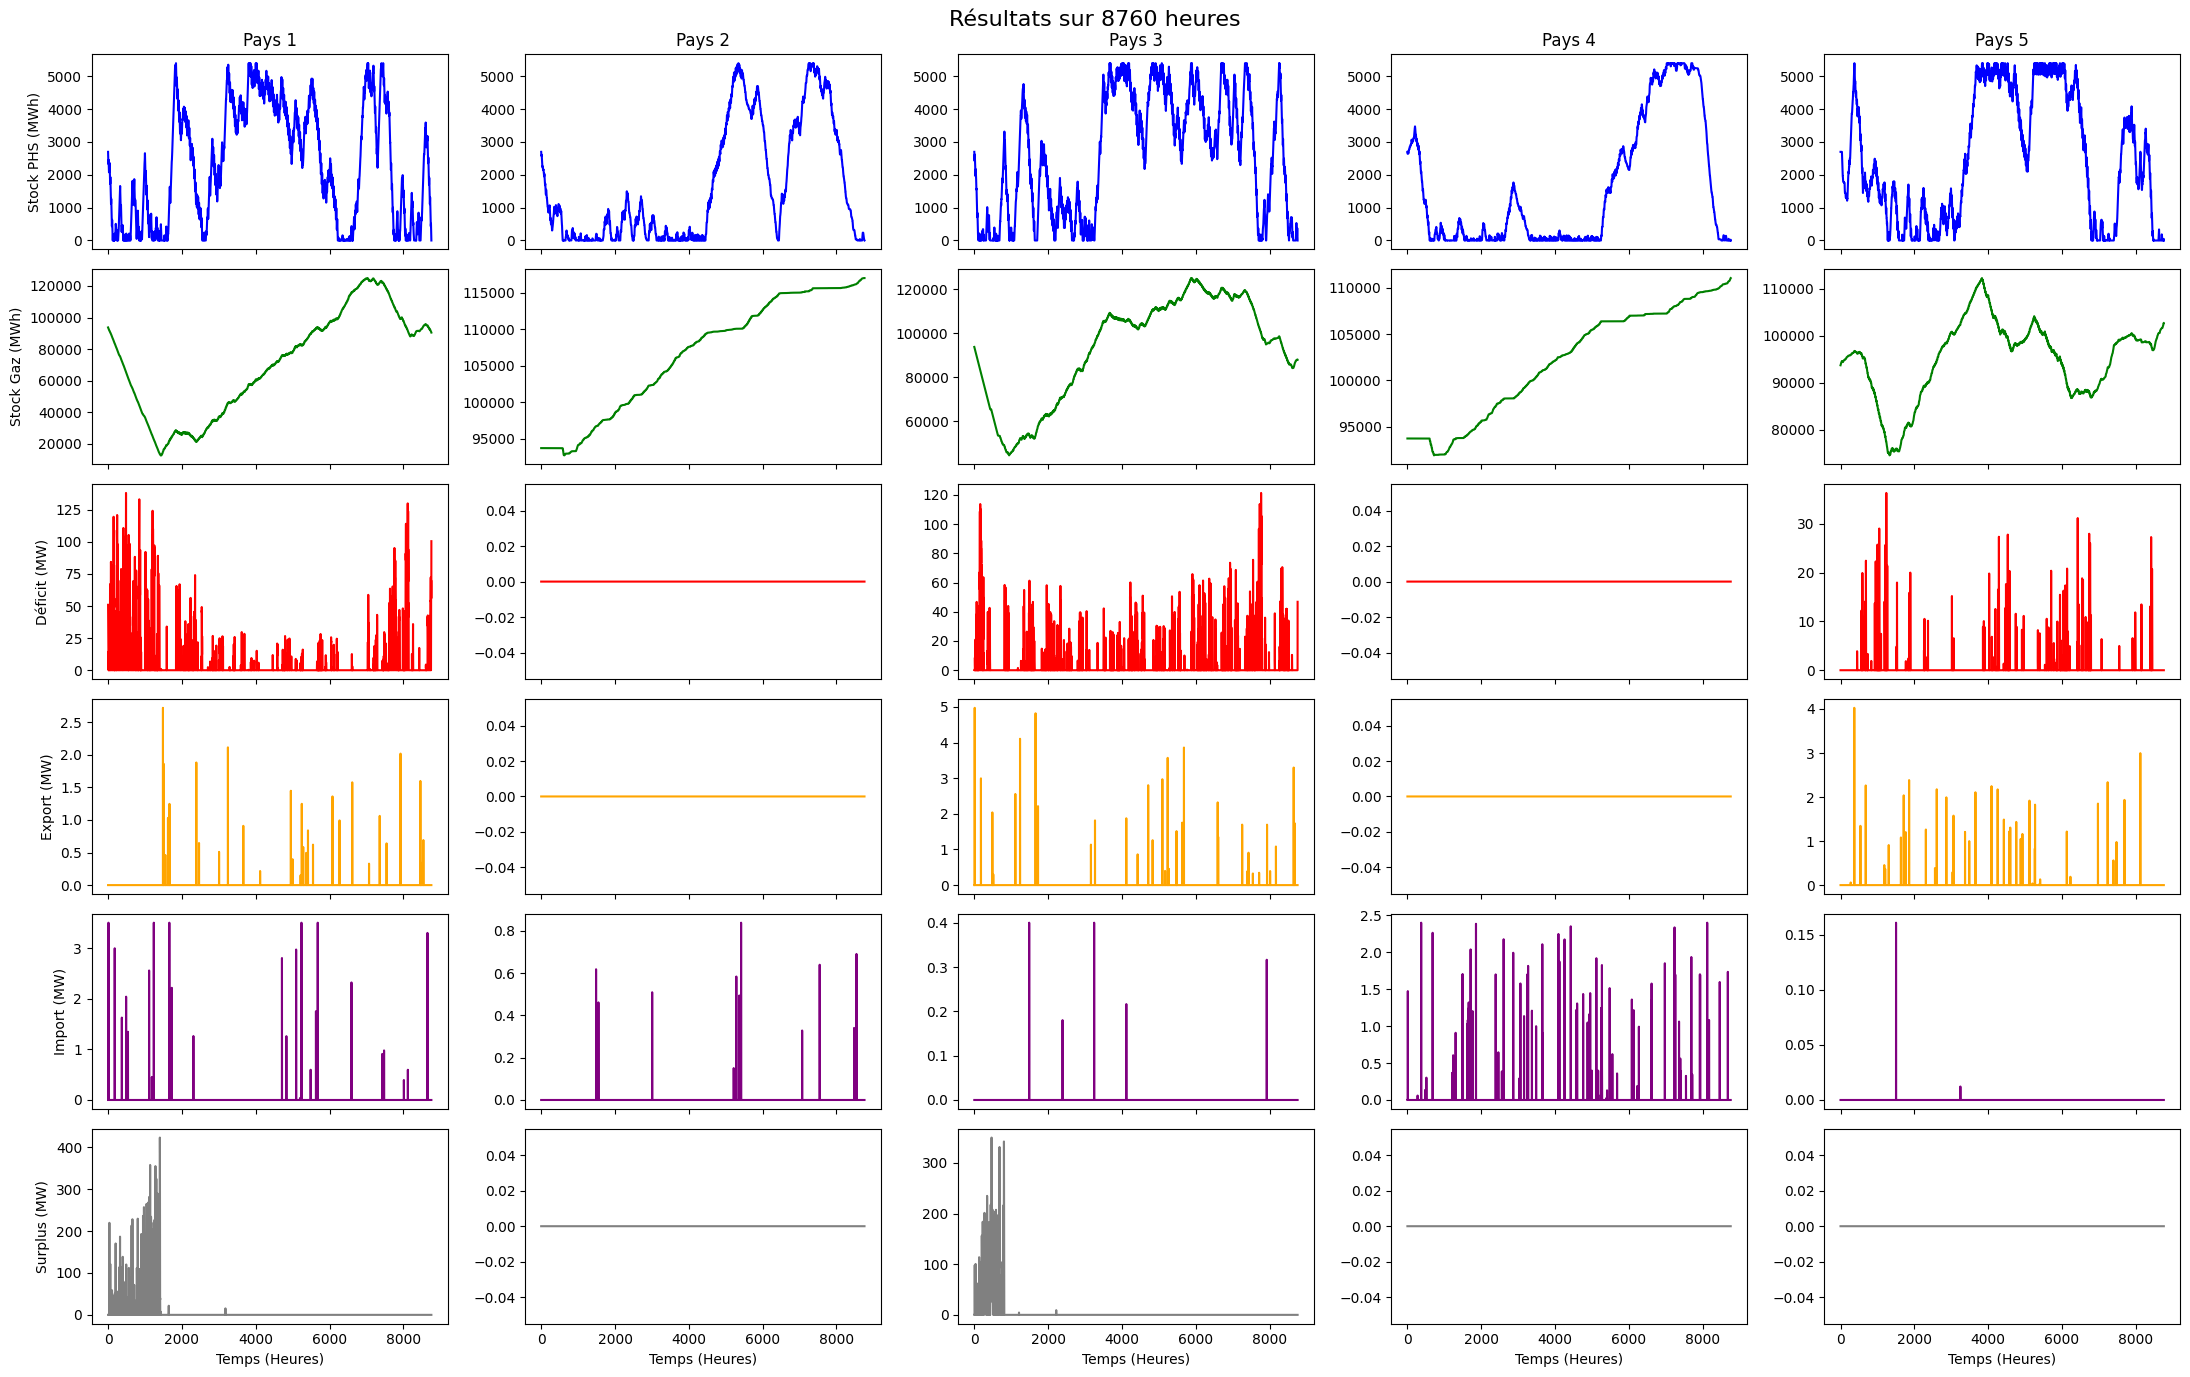

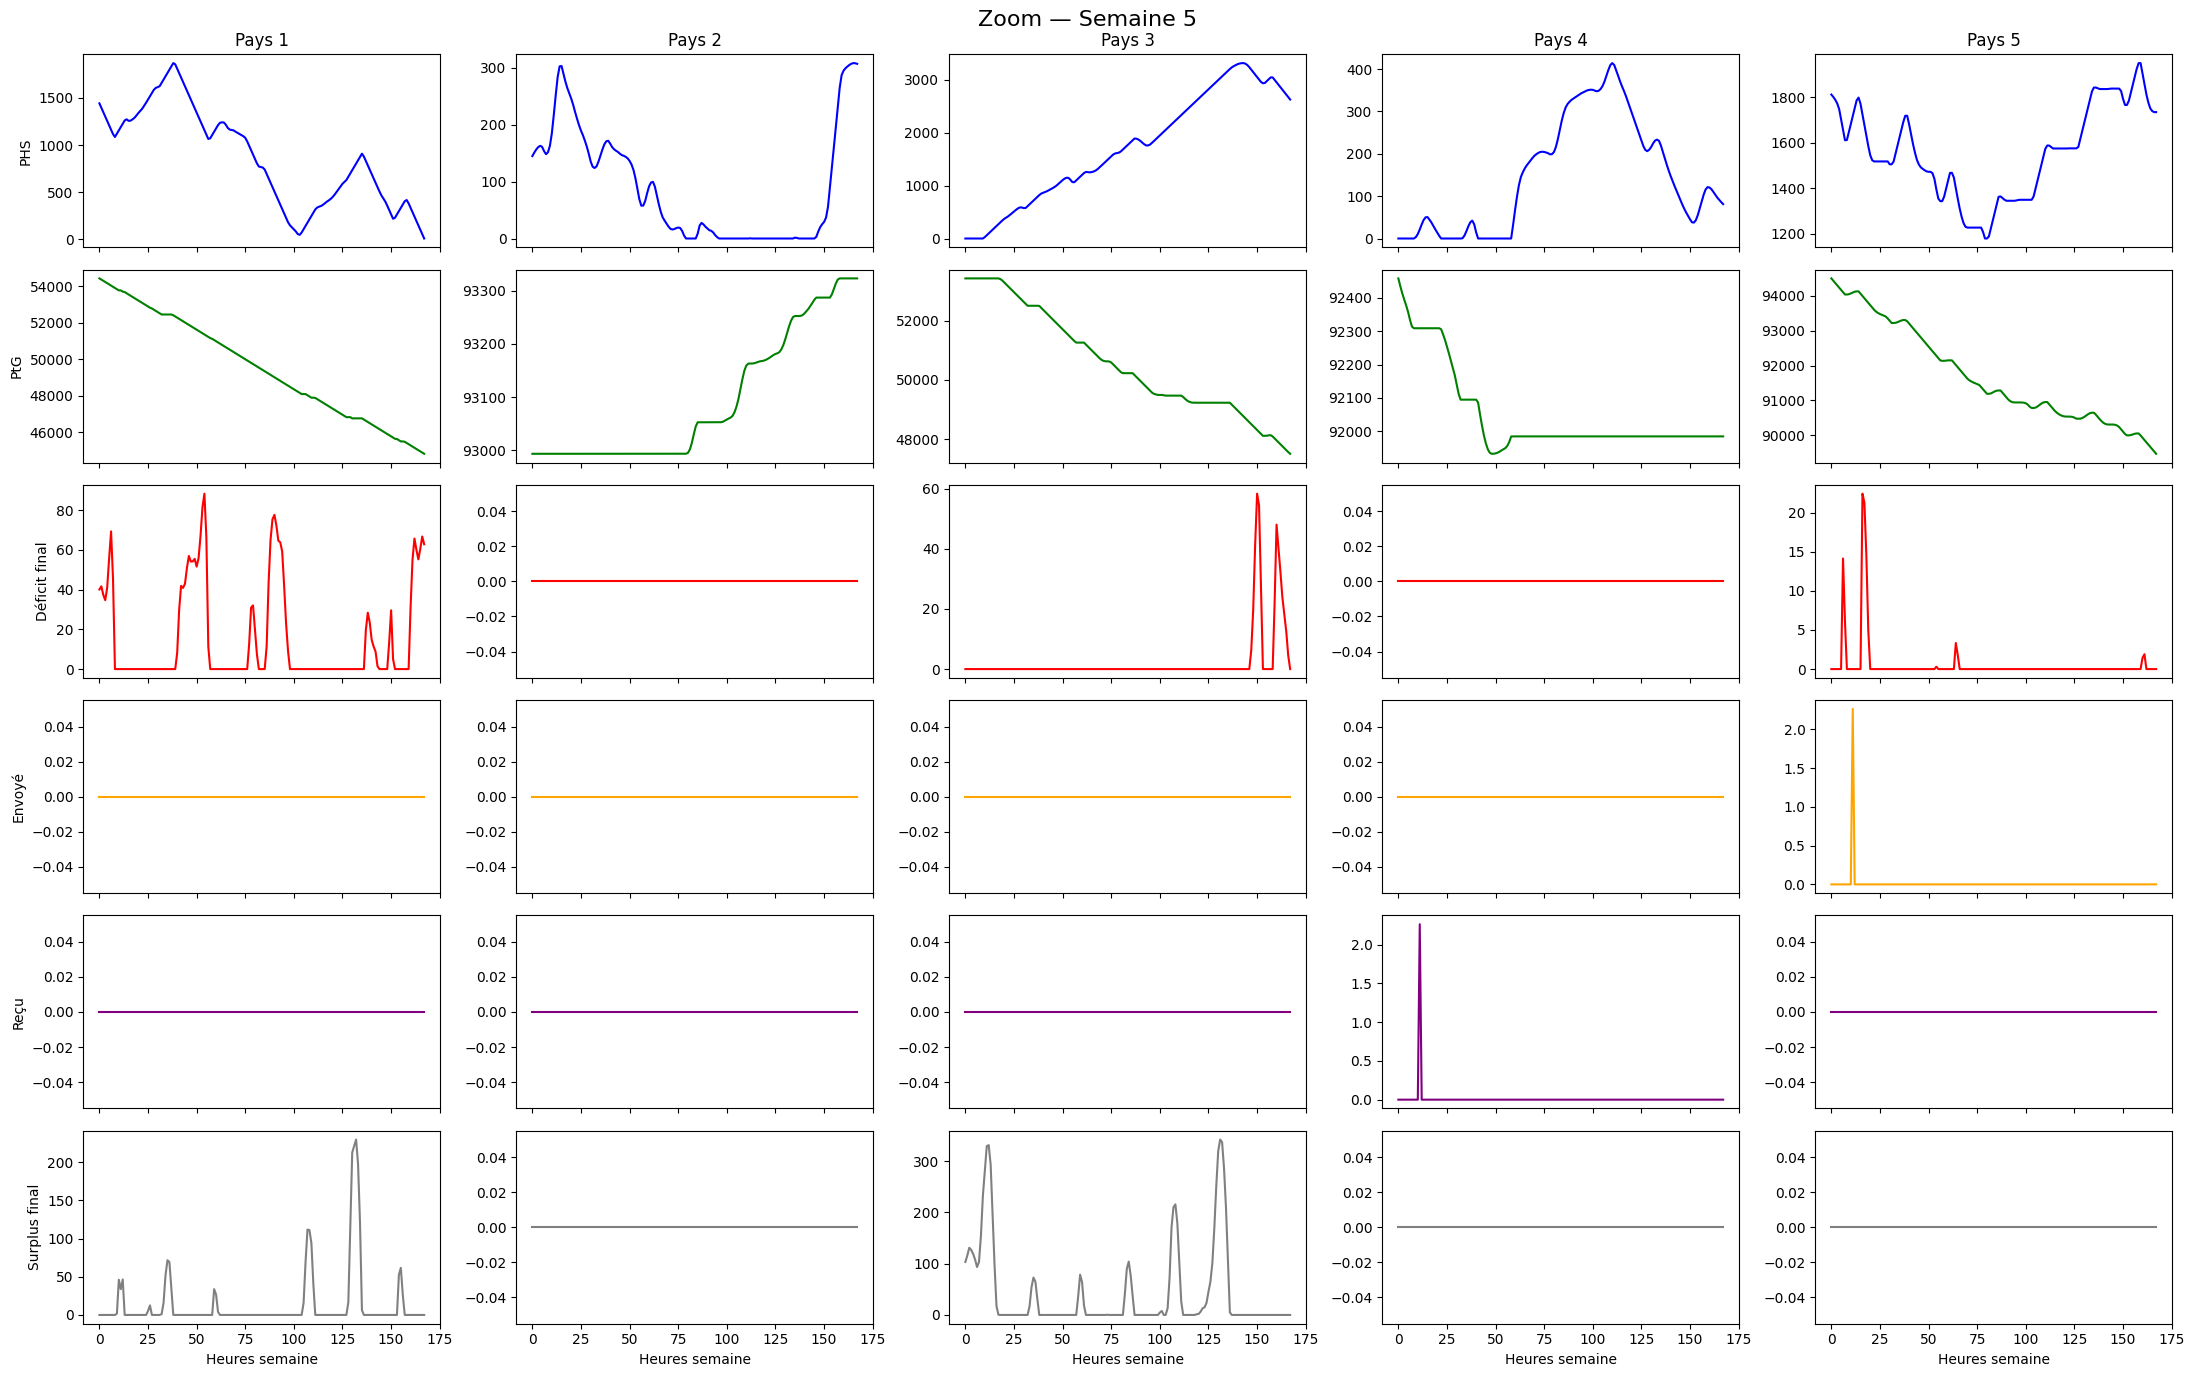

In [22]:
aff.plot_graphs(result_separe)

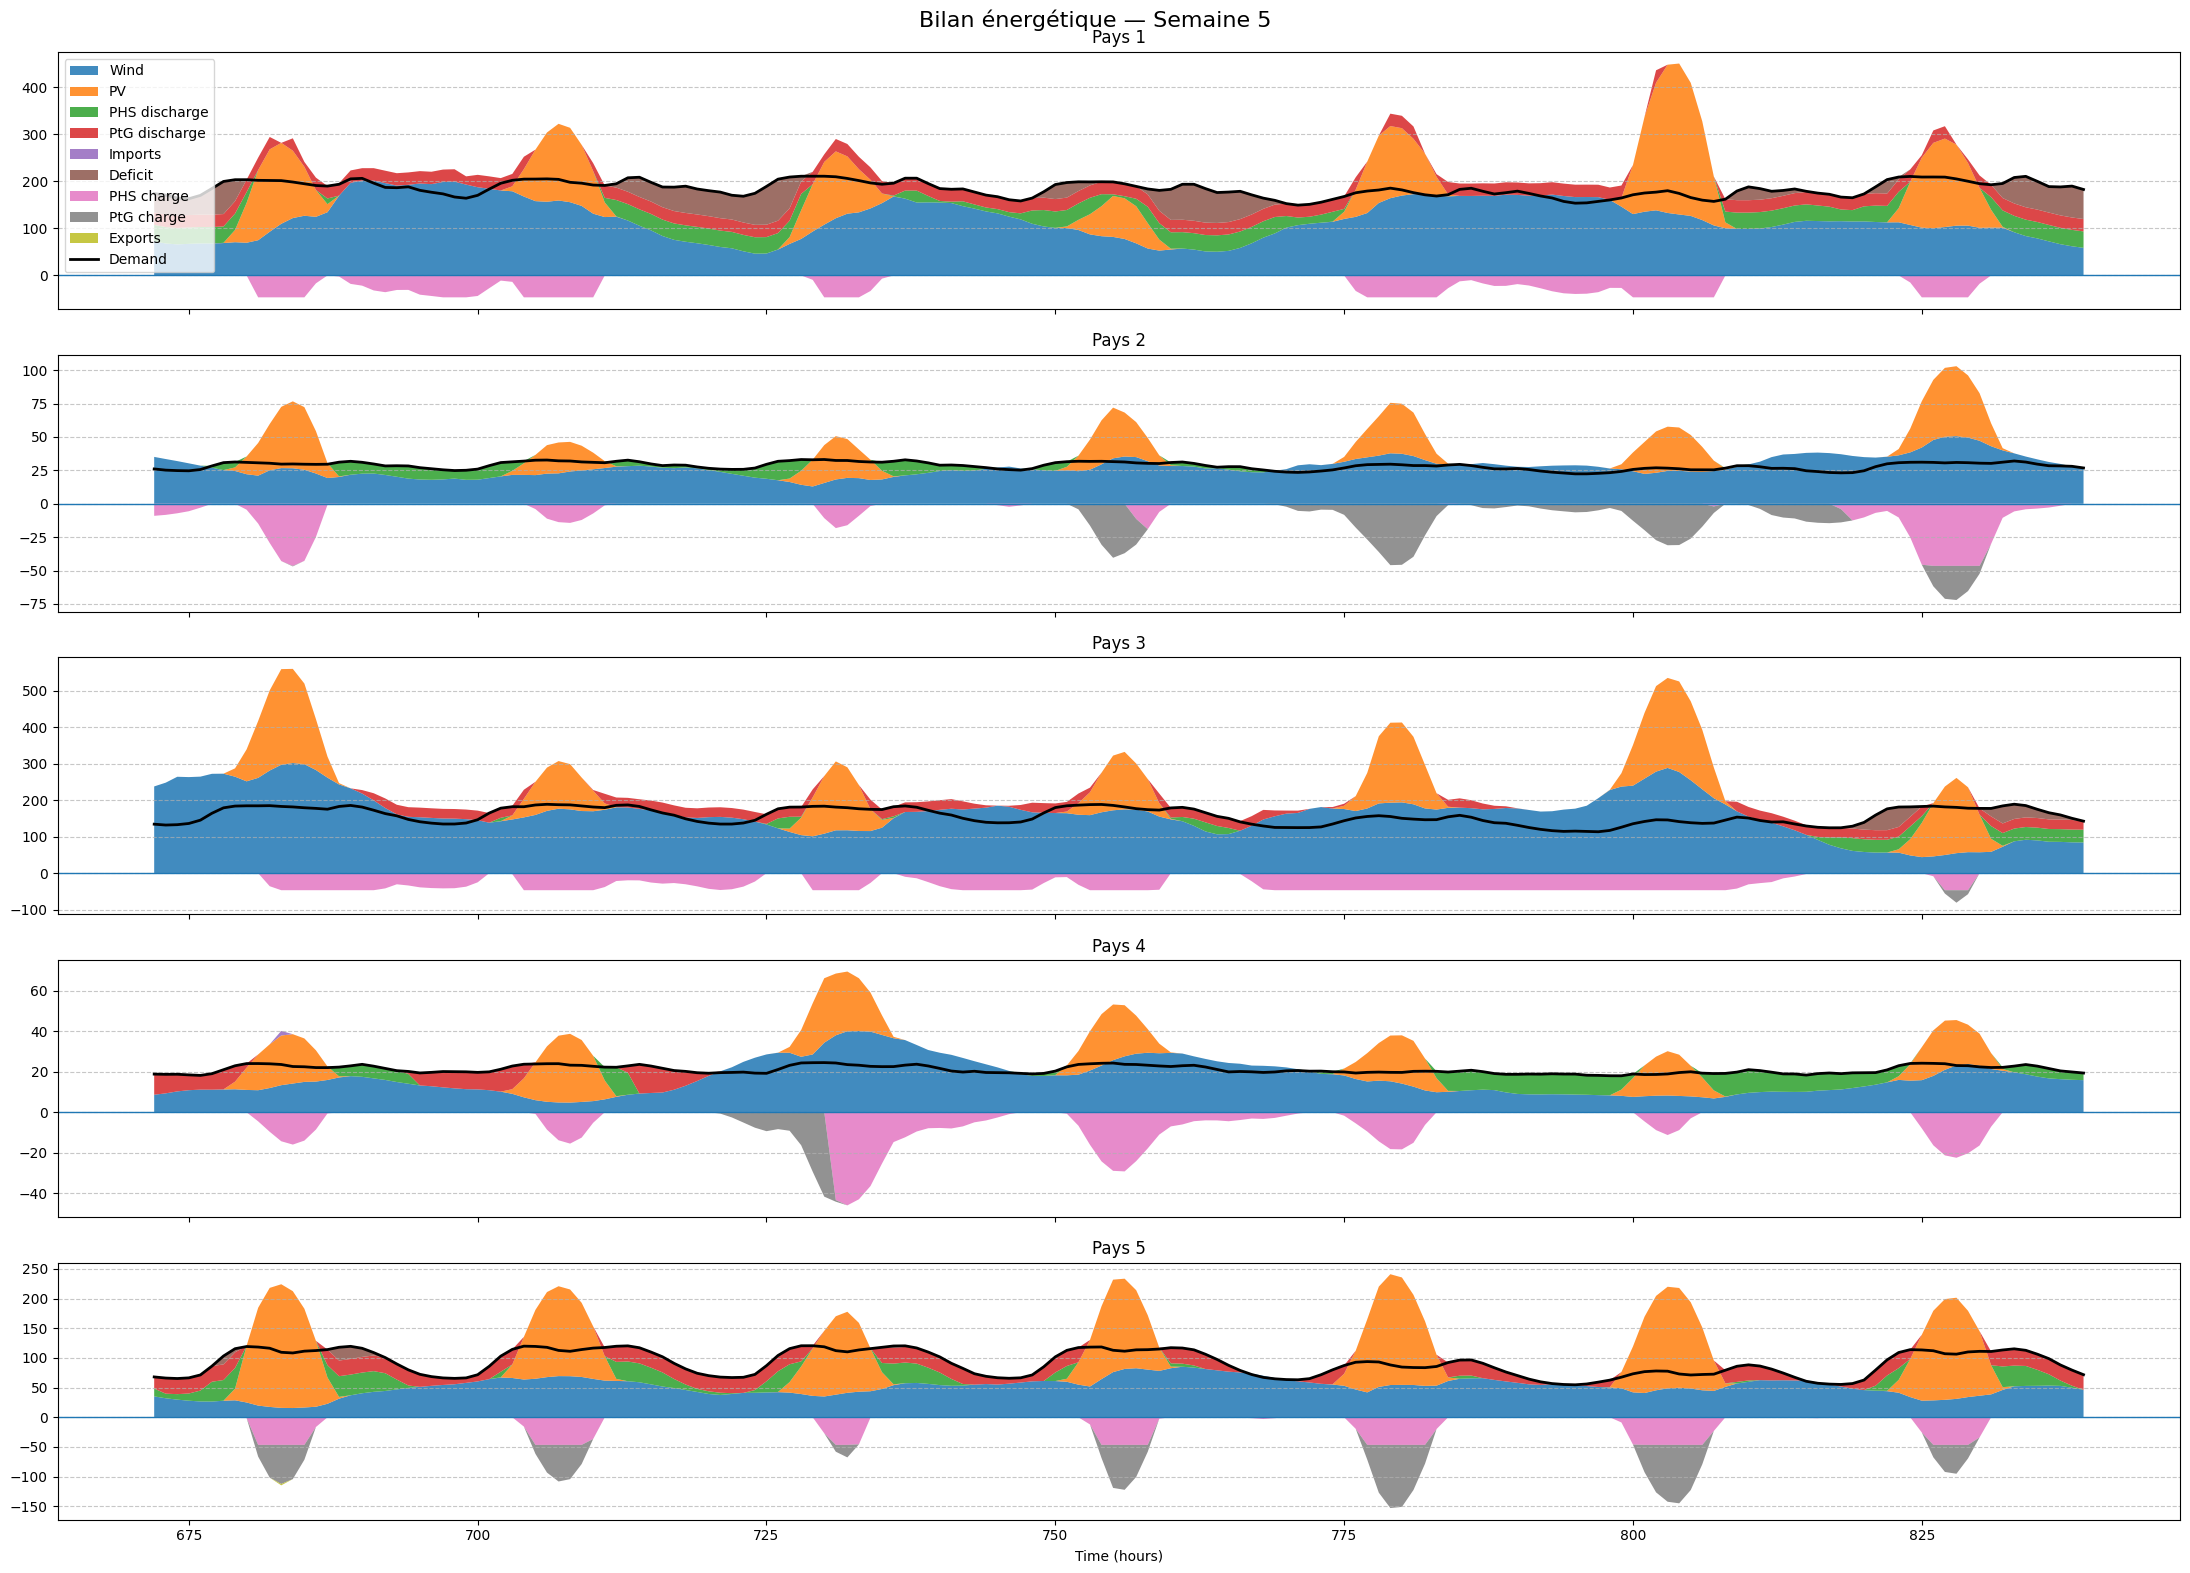

In [23]:
aff.plot_global_graph(result_separe, demand_N=demand_N, wind_N=wind_N, wind_cap_N=wind_cap_N, solar_N=solar_N, solar_cap_N=solar_cap_N, ptg_eff=ptg_eff, phs_eff=phs_eff, semaine=5)

### 2.3 Différence entre les deux modèles de la quantité d'électricité non servie

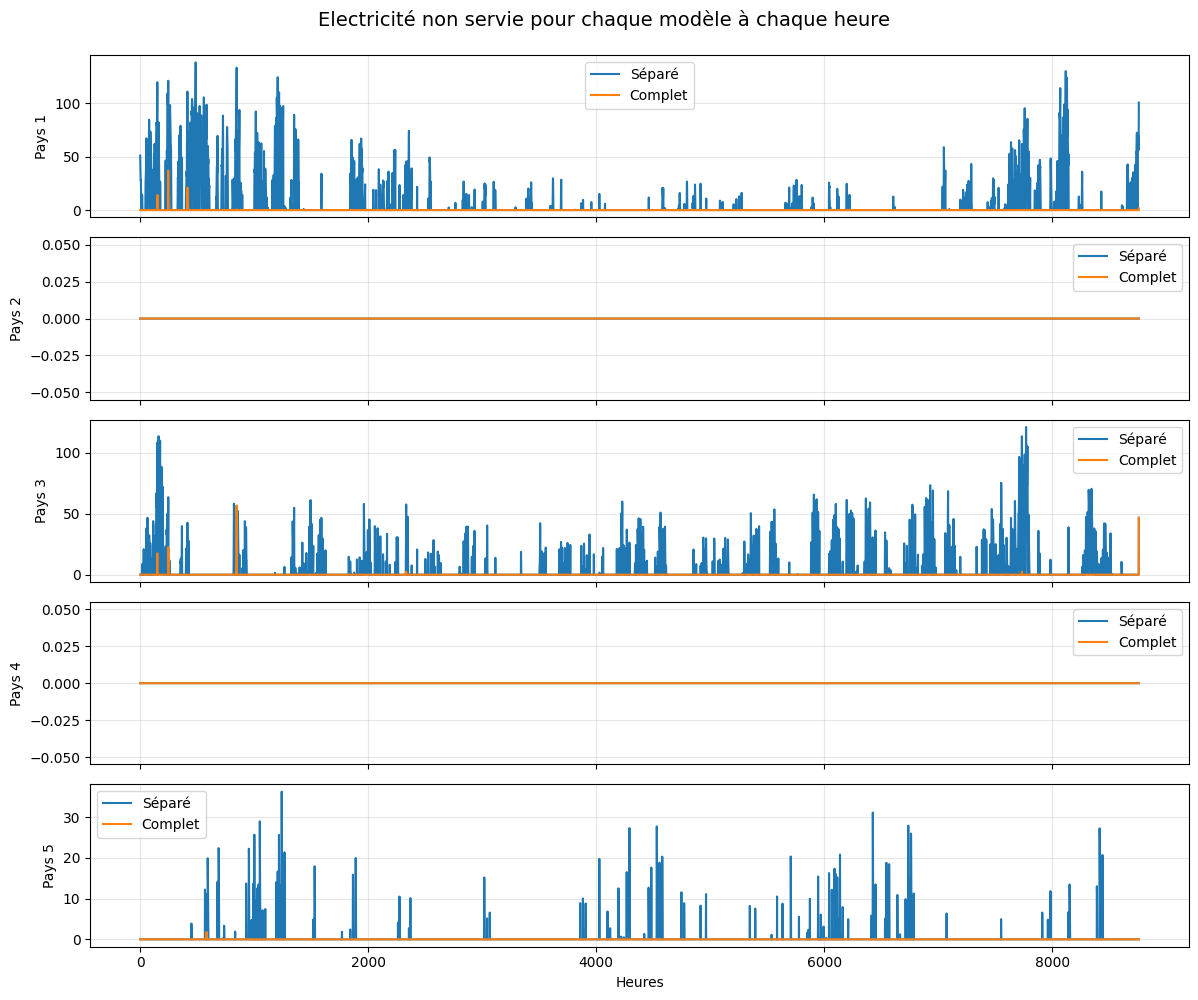

In [24]:
deficit_separe = (result_separe['deficit_final']) # électricité non servie à chaque heure dans le modèle séparé
deficit_complet = (result_complet['deficit_final']) # électricité non servie à chaque heure dans le modèle complet

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i in range(5):
    axes[i].plot(deficit_separe[:, i], label='Séparé')
    axes[i].plot(deficit_complet[:, i], label='Complet')
    #axes[i].plot(demand_N[:, i], label='Demande', c='gray', alpha=0.5)
    axes[i].set_ylabel(f'Pays {i+1}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Heures')

fig.suptitle('Electricité non servie pour chaque modèle à chaque heure', fontsize=14, y=0.995) # Mettre les unités

plt.tight_layout()
plt.show()

In [25]:
difference = deficit_separe - deficit_complet

indices_sep = np.where(difference < 0)[0] # Les heures auxquelles Séparé renvoit un déficit plus petit que complet
indices_comp = np.where(difference > 0)[0]
print("Nombre total d'heures : ", len(difference))
print("-----------------------------")
print("Nombre d'heures où le résultat sur le déficit est meilleur avec l'algorithme Séparé : ", len(indices_sep))
print("Nombre d'heures où le résultat sur le déficit est meilleur avec l'algorithme Complet : ", len(indices_comp))
print("Nombre de valeurs égales :", len(difference)- len(indices_sep) -len(indices_comp))

#print("Indices:", indices_sep)
#print("Valeurs:", difference[indices_sep])

Nombre total d'heures :  8760
-----------------------------
Nombre d'heures où le résultat sur le déficit est meilleur avec l'algorithme Séparé :  0
Nombre d'heures où le résultat sur le déficit est meilleur avec l'algorithme Complet :  3291
Nombre de valeurs égales : 5469


In [26]:
# Déficit cumulé là où Séparé donne un résultat moins bon
cumul_comp = np.sum(deficit_complet[indices_comp], axis=0) # vecteur de taille 5 : une valeur pour chaque pays
cumul_sep = np.sum(deficit_separe[indices_comp], axis=0)
cumul_dem =np.sum(demand_N[indices_comp], axis=0)
print("Demande cumulée par pays :                       ", np.array2string(cumul_dem, precision=1, suppress_small=True))
print("Déficit cumulé par pays avec le modèle Complet : ", np.array2string(cumul_comp, precision=1, suppress_small=True))
print("Déficit cumulé par pays avec le modèle Séparé :  ", np.array2string(cumul_sep, precision=1, suppress_small=True))
print("-----------------------------")

# Ratios (en pourcent)
ratio_comp = 100*(cumul_comp/cumul_dem)
ratio_sep = 100*(cumul_sep/cumul_dem)
print("Part de demande cumulée non servie (%)")
print("-> Avec le modèle Complet : ",  np.array2string(ratio_comp, precision=0, suppress_small=True))
print("-> Avec le modèle Séparé :  ",  np.array2string(ratio_sep, precision=0, suppress_small=True))

Demande cumulée par pays :                        [481385.6  83064.1 477560.4  60612.9 281533. ]
Déficit cumulé par pays avec le modèle Complet :  [151.7   0.  224.1   0.    3.6]
Déficit cumulé par pays avec le modèle Séparé :   [77480.      0.  52225.2     0.   5148.5]
-----------------------------
Part de demande cumulée non servie (%)
-> Avec le modèle Complet :  [0. 0. 0. 0. 0.]
-> Avec le modèle Séparé :   [16.  0. 11.  0.  2.]


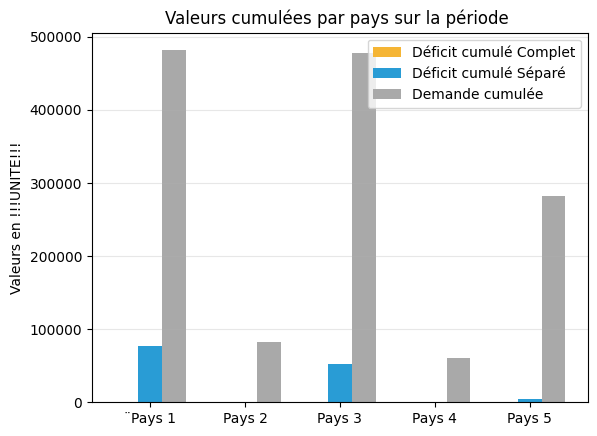

In [28]:
# Même chose mais visuellement

x = np.arange(5)  # [0, 1, 2, 3, 4]
largeur = 0.25

plt.bar(x - largeur, cumul_comp, largeur, label='Déficit cumulé Complet', color="#F5B535")
plt.bar(x, cumul_sep, largeur, label='Déficit cumulé Séparé', color='#299CD5')
plt.bar(x + largeur, cumul_dem, largeur, label='Demande cumulée', color="#A9A9A9")

plt.ylabel('Valeurs en !!!UNITE!!!')
plt.title('Valeurs cumulées par pays sur la période ')
plt.xticks(x, ['¨Pays 1', 'Pays 2', 'Pays 3', 'Pays 4', 'Pays 5'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()